<a href="https://colab.research.google.com/github/letruc271193-dot/btvn/blob/main/btapvn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
#23.1
import folium

# 1. Tọa độ trung tâm: Cơ sở B - UEH (Nguyễn Tri Phương)
ueh_location = [10.7632, 106.6669]

# Tạo bản đồ với Folium, cho phép phóng to/thu nhỏ
m = folium.Map(location=ueh_location, zoom_start=14)

# Thêm các lớp bản đồ (TileLayer) để bật/tắt
folium.TileLayer('OpenStreetMap', name='Bản đồ chuẩn').add_to(m)
folium.TileLayer('CartoDB positron', name='Bản đồ sáng').add_to(m)

# 2. Thêm Marker cho điểm trung tâm
folium.Marker(
    location=ueh_location,
    popup="<b>UEH Cơ sở B</b><br>Trường Đại học Kinh tế TP.HCM",
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(m)

# 3. Danh sách 5 địa điểm công cộng lân cận (tọa độ tham khảo xung quanh Quận 10)
nearby_places = [
    {"name": "Bệnh viện Chợ Rẫy", "location": [10.7576, 106.6588], "type": "Bệnh viện", "color": "blue"},
    {"name": "Vạn Hạnh Mall", "location": [10.7712, 106.6689], "type": "Trung tâm thương mại", "color": "purple"},
    {"name": "UBND Quận 10", "location": [10.7725, 106.6642], "type": "Cơ quan hành chính", "color": "green"},
    {"name": "Bến xe Chợ Lớn", "location": [10.7513, 106.6545], "type": "Bến xe", "color": "orange"},
    {"name": "Siêu thị Co.opmart", "location": [10.7628, 106.6582], "type": "Siêu thị", "color": "lightgray"}
]

# Vòng lặp thêm Marker cho từng địa điểm lân cận
for place in nearby_places:
    folium.Marker(
        location=place["location"],
        popup=f"<b>{place['name']}</b><br>Loại: {place['type']}",
        icon=folium.Icon(color=place["color"], icon='map-marker')
    ).add_to(m)

# Thêm LayerControl vào góc phải để bật/tắt các lớp dữ liệu
folium.LayerControl().add_to(m)
display(m)

In [115]:
#23.2
import pandas as pd
import folium
from geopy.distance import geodesic

# 1. Điểm trung tâm: UEH Cơ sở A (59C Nguyễn Đình Chiểu)
center_coords = (10.7828, 106.6958)

# 2. Danh sách tọa độ gốc (đã được fix cứng để chạy ngay)
locations = {
    "Chợ Bến Thành": (10.7719, 106.6983),
    "Dinh Độc Lập": (10.7770, 106.6954),
    "Bưu điện Trung tâm": (10.7798, 106.7000),
    "Landmark 81": (10.7948, 106.7218),
    "Sân bay Tân Sơn Nhất": (10.8185, 106.6588),
    "Chợ Bình Tây": (10.7501, 106.6508),
    "Thảo Cầm Viên": (10.7876, 106.7053),
    "Bến Nhà Rồng": (10.7634, 106.7071),
    "Hồ Con Rùa": (10.7826, 106.6961),
    "Nhà thờ Đức Bà": (10.7797, 106.6990)
}

data = []

# 3. Tính khoảng cách trực tiếp từ bộ tọa độ
print("Đang tính toán khoảng cách...")
for name, coords in locations.items():
    # Tính khoảng cách đường chim bay (Geodesic distance)
    dist = geodesic(center_coords, coords).kilometers

    data.append({
        "Địa điểm": name,
        "Vĩ độ": coords[0],
        "Kinh độ": coords[1],
        "Khoảng cách (km)": round(dist, 2)
    })

# 4. Hiển thị bảng dữ liệu
df = pd.DataFrame(data)
# Sắp xếp lại bảng theo khoảng cách từ gần đến xa cho chuyên nghiệp
df = df.sort_values(by="Khoảng cách (km)").reset_index(drop=True)
display(df)

# 5. Khởi tạo và vẽ bản đồ Folium
m = folium.Map(location=center_coords, zoom_start=13)

# Marker cho điểm trung tâm (UEH)
folium.Marker(
    center_coords,
    popup="<b>UEH Cơ sở A (Trung tâm)</b>",
    icon=folium.Icon(color="red", icon="university", prefix='fa')
).add_to(m)

# Vẽ Marker và đường nối cho các điểm vệ tinh
for _, row in df.iterrows():
    dest_coords = (row["Vĩ độ"], row["Kinh độ"])

    # Marker điểm đến
    folium.Marker(
        dest_coords,
        popup=f"<b>{row['Địa điểm']}</b><br>Khoảng cách: {row['Khoảng cách (km)']} km",
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(m)

    # Vẽ đường thẳng thể hiện vùng phục vụ/khoảng cách không gian
    folium.PolyLine(
        locations=[center_coords, dest_coords],
        color="green",
        weight=2,
        opacity=0.6,
        dash_array='5, 5' # Tạo nét đứt
    ).add_to(m)
m

Đang tính toán khoảng cách...


,Địa điểm,Vĩ độ,Kinh độ,Khoảng cách (km)
0,Hồ Con Rùa,10.7826,106.6961,0.04
1,Nhà thờ Đức Bà,10.7797,106.6990,0.49
2,Bưu điện Trung tâm,10.7798,106.7000,0.57
3,Dinh Độc Lập,10.7770,106.6954,0.64
4,Thảo Cầm Viên,10.7876,106.7053,1.17
5,Chợ Bến Thành,10.7719,106.6983,1.24
6,Bến Nhà Rồng,10.7634,106.7071,2.48
7,Landmark 81,10.7948,106.7218,3.14
8,Sân bay Tân Sơn Nhất,10.8185,106.6588,5.65
9,Chợ Bình Tây,10.7501,106.6508,6.11


In [116]:

#23.3
import folium
from folium.plugins import HeatMap
import numpy as np
import pandas as pd

#GIẢ LẬP DỮ LIỆU TỌA ĐỘ (Đơn hàng / Khách hàng)
np.random.seed(42) # Cố định seed để kết quả không đổi sau mỗi lần chạy

# Giả lập cụm khách hàng chính (Ví dụ: Khu vực trung tâm Quận 1, Quận 3)
lat_center, lon_center = 10.7769, 106.7009
points_center = 500
lat1 = np.random.normal(lat_center, 0.015, points_center)
lon1 = np.random.normal(lon_center, 0.015, points_center)

# Giả lập cụm khách hàng thứ hai (Ví dụ: Khu vực dân cư đông đúc ở Quận 5, Quận 10)
lat_cluster2, lon_cluster2 = 10.7550, 106.6600
points_cluster2 = 300
lat2 = np.random.normal(lat_cluster2, 0.01, points_cluster2)
lon2 = np.random.normal(lon_cluster2, 0.01, points_cluster2)

# Gộp dữ liệu
latitudes = np.concatenate([lat1, lat2])
longitudes = np.concatenate([lon1, lon2])

# Tạo DataFrame
df_orders = pd.DataFrame({'Latitude': latitudes, 'Longitude': longitudes})
# KHỞI TẠO BẢN ĐỒ VÀ THÊM LỚP HEATMAP
# Tạo bản đồ gốc, căn giữa tại TP.HCM.
# Dùng tiles 'CartoDB positron' để nền bản đồ sáng, làm nổi bật heatmap
m = folium.Map(location=[10.76, 106.68], zoom_start=13, tiles='CartoDB positron')

# Chuyển đổi DataFrame thành list các tọa độ để đưa vào HeatMap
heat_data = [[row['Latitude'], row['Longitude']] for index, row in df_orders.iterrows()]

# Cấu hình Heatmap
HeatMap(heat_data,
        radius=15,     # Bán kính lan tỏa của mỗi điểm
        blur=10,       # Độ mờ, giúp các điểm hòa trộn tự nhiên
        max_zoom=1,
        gradient={0.4: 'blue', 0.65: 'yellow', 1.0: 'red'} # Màu sắc từ lạnh đến nóng
       ).add_to(m)
m


-Giải thích ý nghĩa 23.3
Khi bản đồ hiển thị các vùng màu đỏ (vùng nóng - mật độ cao) và vùng màu xanh/vàng (vùng lạnh - mật độ thấp), người quản lý có thể rút ra các quyết định mang tính chiến lược:
Tối ưu hóa mạng lưới Logistics và Kho bãi: Các vùng nóng (điểm tụ tập nhiều đơn hàng/khách hàng) là những khu vực lý tưởng để đặt các kho trung chuyển (Distribution Centers/Hubs) hoặc trạm giao nhận. Việc đặt kho gần vùng nóng giúp giảm thiểu đáng kể chi phí vận tải chặng cuối (last-mile delivery) và rút ngắn thời gian giao hàng (lead time).
Phân bổ nguồn lực hiệu quả: Dựa vào mật độ, doanh nghiệp có thể phân bổ nhân sự (tài xế, nhân viên giao hàng, nhân viên tư vấn) hợp lý hơn. Tập trung nguồn lực vào các vùng nóng trong giờ cao điểm để tránh ách tắc hoặc quá tải dịch vụ.
Phân tích hành vi và duy trì khách hàng (Retention): Nếu áp dụng dữ liệu về tỉ lệ rời bỏ của khách hàng (churn rate) lên bản đồ nhiệt, quản lý có thể trực quan hóa được các khu vực địa lý nào đang có vấn đề về chất lượng dịch vụ. Từ đó, triển khai các chương trình chăm sóc khách hàng hoặc khuyến mãi nhắm mục tiêu chính xác vào các tọa độ này để cải thiện sự trung thành.
Chiến lược mở rộng thị trường: Phân tích các khu vực có mật độ thấp (những khoảng trắng hoặc vùng xanh) trên bản đồ để đặt câu hỏi: Đây là khu vực tiềm năng chưa được khai thác, hay là khu vực khách hàng không có nhu cầu? Từ đó có chiến lược chạy quảng cáo (Geo-targeted marketing) để kích cầu


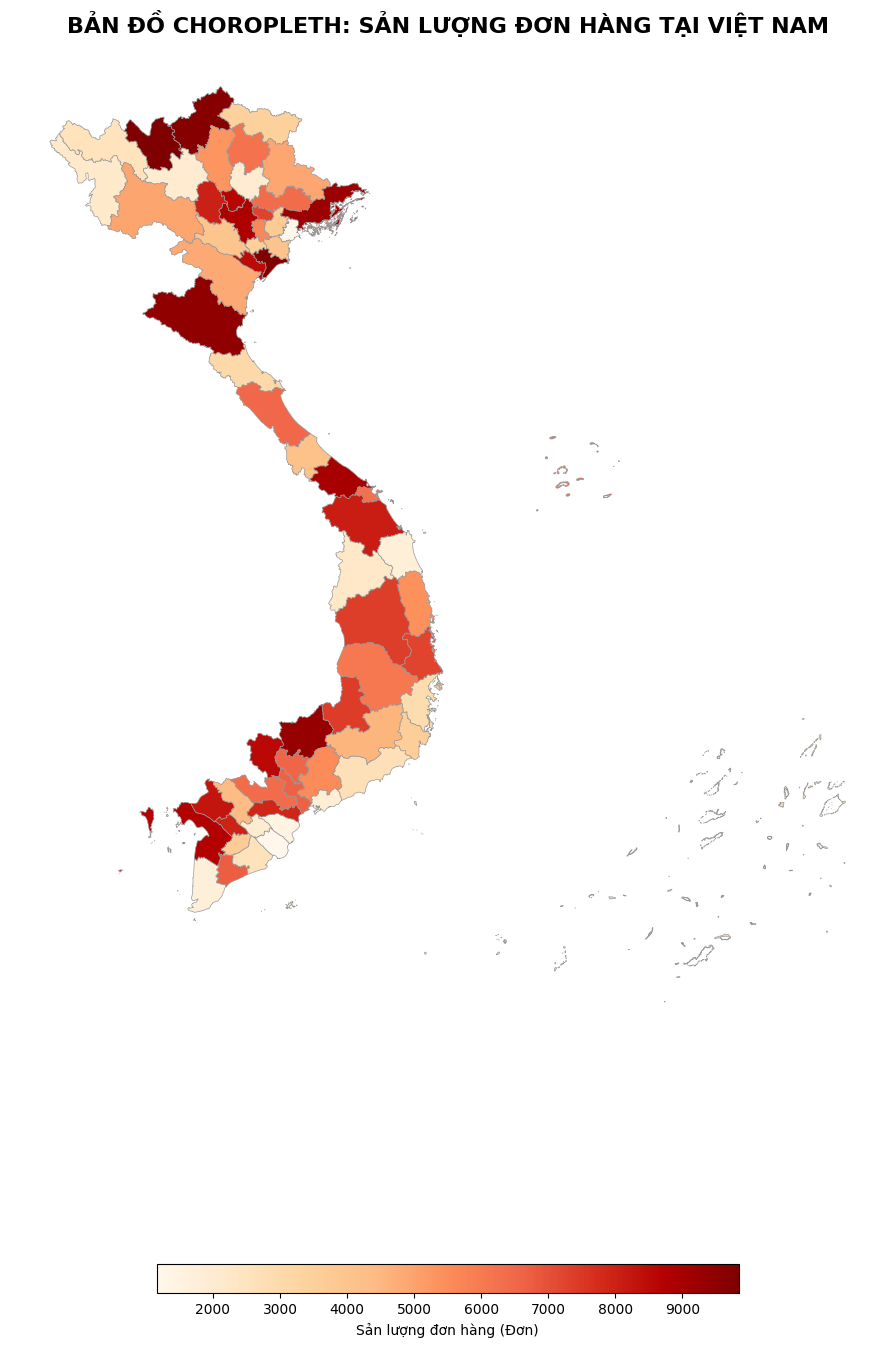

In [117]:
#23.4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu ranh giới hành chính các tỉnh Việt Nam (GeoJSON) từ nguồn mới
url = "https://data.opendevelopmentmekong.net/dataset/999c96d8-fae0-4b82-9a2b-e481f6f50e12/resource/2818c2c5-e9c3-440b-a9b8-3029d7298065/download/diaphantinhenglish.geojson"

# Đọc file dữ liệu không gian
vietnam_map = gpd.read_file(url)

# 2. Giả lập dữ liệu "Sản lượng đơn hàng" (Order Volume) cho ngành Logistics
np.random.seed(42)
data_logistics = pd.DataFrame({
    'Name': vietnam_map['Name'], # Nguồn dữ liệu mới dùng chữ 'N' viết hoa
    'order_volume': np.random.randint(1000, 10000, size=len(vietnam_map))
})

# Kết hợp dữ liệu bản đồ và dữ liệu số (Merge) dựa trên cột 'Name'
merged = vietnam_map.merge(data_logistics, on='Name')

# 3. Vẽ bản đồ Choropleth
fig, ax = plt.subplots(1, 1, figsize=(10, 15))

merged.plot(column='order_volume',
            ax=ax,
            legend=True,
            cmap='OrRd', # Thang màu Cam-Đỏ
            edgecolor='0.6', # Màu viền ranh giới (xám nhạt)
            linewidth=0.5,
            legend_kwds={'label': "Sản lượng đơn hàng (Đơn)",
                         'orientation': "horizontal",
                         'shrink': 0.6}) # Thu nhỏ thanh chú giải cho cân đối

# Tùy chỉnh hiển thị
plt.title('BẢN ĐỒ CHOROPLETH: SẢN LƯỢNG ĐƠN HÀNG TẠI VIỆT NAM', fontsize=16, fontweight='bold')
ax.axis('off') # Tắt khung hệ tọa độ
plt.tight_layout()
plt.show()

-Nhật xét 23.4
Trong lĩnh vực quản trị chuỗi cung ứng, bản đồ này giúp :
Xác định vùng nhu cầu cao: Những khu vực màu đỏ đậm là nơi cần ưu tiên đặt các kho trung chuyển hoặc trung tâm phân phối .
Tối ưu hóa vận tải: Giúp nhà quản lý điều phối đội xe tập trung vào các khu vực có mật độ đơn hàng lớn để giảm chi phí trên mỗi km vận chuyển.


In [118]:
#23.5

import folium
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from IPython.display import display

# 1. Tọa độ Trung tâm phân phối (DC) - Giả định tại TP.HCM
dc_lat, dc_lon = 10.7613, 106.6688
dc_location = (dc_lat, dc_lon)

# 2. Tạo dữ liệu giả lập cho 200 điểm khách hàng xung quanh DC
np.random.seed(42) # Cố định seed để kết quả không đổi mỗi lần chạy
num_customers = 200
# Tạo độ lệch tọa độ ngẫu nhiên (0.1 độ tương đương khoảng 11km)
lat_offsets = np.random.uniform(-0.12, 0.12, num_customers)
lon_offsets = np.random.uniform(-0.12, 0.12, num_customers)

customers = pd.DataFrame({
    'id': range(1, num_customers + 1),
    'lat': dc_lat + lat_offsets,
    'lon': dc_lon + lon_offsets
})

# 3. Tính khoảng cách từ DC đến từng khách hàng (đơn vị: km)
def calculate_distance(row):
    return geodesic(dc_location, (row['lat'], row['lon'])).km

customers['distance_km'] = customers.apply(calculate_distance, axis=1)

# Phân loại khách hàng vào các vùng phục vụ
customers['zone'] = pd.cut(customers['distance_km'],
                           bins=[0, 3, 5, 10, float('inf')],
                           labels=['Vùng 1 (< 3km)', 'Vùng 2 (3-5km)', 'Vùng 3 (5-10km)', 'Ngoài vùng (> 10km)'])

# 4. Khởi tạo bản đồ Folium
m = folium.Map(location=dc_location, zoom_start=12)

# Đánh dấu vị trí Trung tâm phân phối
folium.Marker(
    location=dc_location,
    popup='<b>Trung tâm Phân phối (DC)</b>',
    icon=folium.Icon(color='red', icon='home')
).add_to(m)

# Vẽ các vòng bán kính phục vụ (Folium sử dụng đơn vị mét)
radii_km = [3, 5, 10]
colors = ['green', 'blue', 'orange']

for radius, color in zip(radii_km, colors):
    folium.Circle(
        radius=radius * 1000,
        location=dc_location,
        popup=f'Bán kính {radius}km',
        color=color,
        fill=True,
        fill_opacity=0.05,
        weight=2
    ).add_to(m)

# Thêm các điểm khách hàng lên bản đồ
for idx, row in customers.iterrows():
    # Chọn màu dựa trên khoảng cách
    if row['distance_km'] <= 3:
        point_color = 'green'
    elif row['distance_km'] <= 5:
        point_color = 'blue'
    elif row['distance_km'] <= 10:
        point_color = 'orange'
    else:
        point_color = 'gray' # Khách hàng nằm ngoài phạm vi 10km

    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=4,
        color=point_color,
        fill=True,
        fill_color=point_color,
        fill_opacity=0.7,
        popup=f"KH {row['id']}<br>Cách DC: {row['distance_km']:.2f} km"
    ).add_to(m)


display(m)

# 5. Xuất thống kê dữ liệu để làm báo cáo đánh giá
print("--- THỐNG KÊ MẬT ĐỘ KHÁCH HÀNG THEO VÙNG PHỤC VỤ ---")
zone_stats = customers['zone'].value_counts().sort_index()
total_customers = len(customers)

for zone, count in zone_stats.items():
    percentage = (count / total_customers) * 100
    print(f"- {zone}: {count} khách hàng ({percentage:.1f}%)")

--- THỐNG KÊ MẬT ĐỘ KHÁCH HÀNG THEO VÙNG PHỤC VỤ ---
- Vùng 1 (< 3km): 5 khách hàng (2.5%)
- Vùng 2 (3-5km): 14 khách hàng (7.0%)
- Vùng 3 (5-10km): 60 khách hàng (30.0%)
- Ngoài vùng (> 10km): 121 khách hàng (60.5%)


-Đánh giá và đề xuất 23.5
1. Đánh giá khả năng tiếp cận khách hàng:
Vùng 1 (Bán kính < 3km - Vùng xanh lá): Đây là khu vực cốt lõi. Khả năng tiếp cận tại đây là tốt nhất, thời gian giao hàng (lead time) cực kỳ ngắn. Phù hợp cho các dịch vụ giao hàng hỏa tốc (trong vòng 1-2 giờ).
Vùng 2 (Bán kính 3km - 5km - Vùng xanh dương): Đây là vùng hoạt động tiêu chuẩn. Mật độ khách hàng thường tập trung đông. Khả năng tiếp cận vẫn duy trì ở mức hiệu quả về chi phí, phù hợp với các tuyến giao hàng gom chuyến (milk-run) trong nửa ngày.
Vùng 3 (Bán kính 5km - 10km - Vùng màu cam): Khoảng cách bắt đầu xa hơn, chi phí vận tải chặng cuối (last-mile delivery) sẽ tăng đáng kể nếu giao các đơn lẻ tẻ.
Ngoài 10km (Điểm màu xám): Vượt ra khỏi vùng phục vụ tối ưu của một trung tâm phân phối đô thị. Việc giao trực tiếp từ DC này sẽ không mang lại hiệu quả kinh tế.
2. Đề xuất phạm vi hoạt động tối ưu:
Phạm vi tối ưu: Nên giới hạn cam kết phục vụ trực tiếp từ DC này ở mức bán kính 5km. Đây là điểm cân bằng giữa việc tối đa hóa lượng khách hàng và kiểm soát chi phí vận hành đội xe.
Chiến lược cho vùng > 5km: * Đối với khách hàng ở bán kính 5-10km: Thay vì giao trực tiếp từng đơn từ DC, nên gom đơn và thiết lập các trạm trung chuyển nhỏ (cross-docking station) hoặc sử dụng tủ khóa thông minh (smart lockers) để giảm chi phí giao hàng chặng cuối.
Đối với khách hàng > 10km: Cân nhắc thuê ngoài các đơn vị logistics thứ ba (3PL) để xử lý hoặc xây dựng thêm một DC khác nếu dung lượng thị trường đủ lớn.


Bắt đầu tải dữ liệu...
Đã tải thành công mạng lưới giao thông cho: District 10, Ho Chi Minh City, Vietnam
Đang vẽ bản đồ...


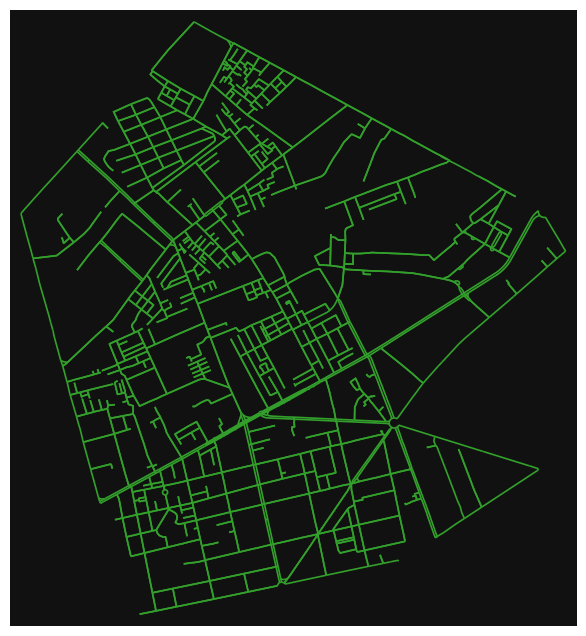


--- KẾT QUẢ PHÂN TÍCH MẠNG LƯỚI CƠ BẢN ---
1. Tổng số lượng nút (Nodes - các điểm giao cắt/điểm cuối): 912
2. Tổng số lượng đoạn đường (Edges): 2,142
3. Chiều dài đoạn đường trung bình: 75.99 mét
4. Tổng chiều dài mạng lưới đường bộ: 162.77 km

--- CẤU TRÚC NÚT GIAO ---
- Ngã ba (3 đường giao nhau): 563 nút
- Ngã tư (4 đường giao nhau): 133 nút


In [119]:
#23.6
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# 1 Cấu hình OSMnx để sử dụng cache (tải nhanh hơn cho các lần sau)
ox.settings.use_cache = True

print("Bắt đầu tải dữ liệu...")

# 2: Tải dữ liệu mạng lưới giao thông đường bộ
# Lấy dữ liệu mạng lưới đường dành cho phương tiện cơ giới (drive) tại Quận 10
place_name = "District 10, Ho Chi Minh City, Vietnam"
try:
    G = ox.graph_from_place(place_name, network_type='drive')
    print(f"Đã tải thành công mạng lưới giao thông cho: {place_name}")
except Exception as e:
    print(f"Có lỗi xảy ra khi tải dữ liệu: {e}")

#  3: Trực quan hóa mạng đường trên bản đồ
print("Đang vẽ bản đồ...")
# Vẽ đồ thị với các nút (nodes) ẩn đi để dễ nhìn mạng lưới đường (edges)
fig, ax = ox.plot_graph(G, node_size=0, edge_color='#33a02c', edge_linewidth=1.2, bgcolor='#111111')

# 4: Thực hiện một số phân tích cơ bản
print("\n--- KẾT QUẢ PHÂN TÍCH MẠNG LƯỚI CƠ BẢN ---")

# Tính toán các thống kê tổng quát
# OSMnx tự động tính các chỉ số như số node, số edge, số giao lộ...
stats = ox.basic_stats(G)

# In ra các chỉ số theo yêu cầu của đề bài
print(f"1. Tổng số lượng nút (Nodes - các điểm giao cắt/điểm cuối): {stats['n']:,}")
print(f"2. Tổng số lượng đoạn đường (Edges): {stats['m']:,}")

# Chuyển đồ thị sang định dạng GeoDataFrame để dễ tính toán chi tiết chiều dài
nodes, edges = ox.graph_to_gdfs(G)

# Tính chiều dài đường trung bình
mean_length = edges['length'].mean()
print(f"3. Chiều dài đoạn đường trung bình: {mean_length:.2f} mét")

# Tính tổng chiều dài toàn bộ mạng lưới
total_length_km = edges['length'].sum() / 1000
print(f"4. Tổng chiều dài mạng lưới đường bộ: {total_length_km:.2f} km")

# Phân tích thêm: Số lượng các loại nút giao
streets_per_node = stats.get('streets_per_node_counts', {})
print("\n--- CẤU TRÚC NÚT GIAO ---")
print(f"- Ngã ba (3 đường giao nhau): {streets_per_node.get(3, 0):,} nút")
print(f"- Ngã tư (4 đường giao nhau): {streets_per_node.get(4, 0):,} nút")

-Vai trò 23.6
Dữ liệu mạng lưới giao thông , đóng vai trò then chốt trong các lĩnh vực sau:
Tối ưu hóa chuỗi cung ứng đô thị và Logistics: Đối với bài toán giao hàng chặng cuối (last-mile delivery), dữ liệu mạng lưới giúp thuật toán AI tính toán lộ trình di chuyển tối ưu cho shipper hoặc các trạm phân phối. Nó giúp AI hiểu rõ các ràng buộc vật lý (đường một chiều, đường cấm tải, chiều dài đoạn đường) để giảm thiểu thời gian và chi phí vận hành.
Định tuyến động và Giảm ùn tắc (Smart Routing): Các hệ thống như Google Maps sử dụng mạng lưới đường phố kết hợp với dữ liệu thời gian thực để huấn luyện các mô hình học máy. AI có thể dự báo các nút thắt cổ chai (bottlenecks) và chủ động điều hướng các luồng phương tiện sang các tuyến đường thay thế.
Phản ứng khẩn cấp hiệu quả (Emergency Response): Trong các đô thị thông minh, AI sử dụng cấu trúc topology của mạng lưới đường (các node và edge) để chạy các thuật toán tìm đường (như Dijkstra hoặc A*) nhằm điều phối xe cứu thương, cứu hỏa đến hiện trường với thời gian ngắn nhất.
Hỗ trợ xe tự lái (Autonomous Vehicles): Dữ liệu đồ thị đường phố cung cấp thông tin nền tảng về cấu trúc hình học của đô thị. Hệ thống AI trên xe tự lái cần các bản đồ có độ phân giải cao, bắt đầu từ dữ liệu mạng lưới cơ bản này, để thiết lập logic di chuyển (chuyển hướng ở ngã tư, nhận diện các điểm giao cắt phức tạp).
Quy hoạch đô thị dựa trên dữ liệu (Data-Driven Urban Planning): Các mô hình AI có thể mô phỏng tác động của việc xây dựng một tuyến đường mới hoặc đóng cửa một cây cầu. Thông qua việc phân tích "mật độ mạng" hoặc "mức độ kết nối" của các node, các nhà quản lý sẽ biết được khu vực nào đang bị cô lập và cần đầu tư hạ tầng giao thông.


Đang tải dữ liệu bản đồ...
Node bắt đầu: 366377622
Node kết thúc: 12856066557

--- KẾT QUẢ SO SÁNH ---
1. Thuật toán Dijkstra:
   - Thời gian thực thi: 0.006616 giây
   - Số lượng node đi qua: 36
2. Thuật toán A*:
   - Thời gian thực thi: 0.003064 giây
   - Số lượng node đi qua: 36

=> Cả hai thuật toán đều tìm ra cùng một tuyến đường tối ưu nhất.


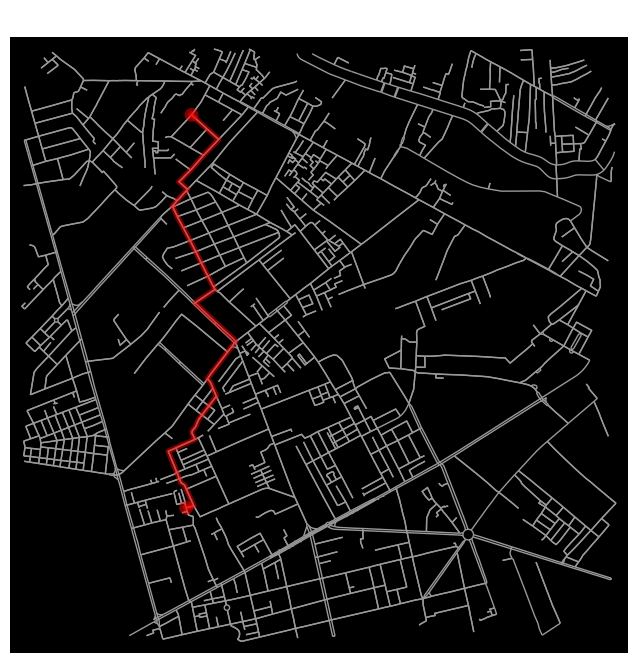

In [120]:
#23.7

import osmnx as ox
import networkx as nx
import time
import matplotlib.pyplot as plt

# 1: TẢI DỮ LIỆU BẢN ĐỒ VÀ TIỀN XỬ LÝ

# Lấy dữ liệu mạng lưới đường bộ (chế độ lái xe) tại khu vực trung tâm (VD: gần Nguyễn Tri Phương, Q.10)
print("Đang tải dữ liệu bản đồ...")
point = (10.7763, 106.6675)
G = ox.graph_from_point(point, dist=1500, network_type='drive')

# Cập nhật thêm thông tin về tốc độ và thời gian di chuyển cho các cạnh (nếu cần dùng weight='travel_time')
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# Chọn ngẫu nhiên 2 điểm: Điểm bắt đầu (origin) và Điểm kết thúc (destination)
nodes = list(G.nodes)
orig_node = nodes[10]   # Có thể thay đổi index để thử các điểm khác
dest_node = nodes[-10]  # Có thể thay đổi index để thử các điểm khác

print(f"Node bắt đầu: {orig_node}")
print(f"Node kết thúc: {dest_node}\n")

# 2: THUẬT TOÁN TÌM ĐƯỜNG

# Thuật toán 1: Dijkstra
start_time_dijkstra = time.time()
# Dijkstra tìm đường ngắn nhất dựa trên trọng số 'length' (khoảng cách vật lý)
route_dijkstra = nx.shortest_path(G, orig_node, dest_node, weight='length', method='dijkstra')
time_dijkstra = time.time() - start_time_dijkstra

# Thuật toán 2: A* (A-Star)
# Định nghĩa hàm Heuristic: Ước lượng khoảng cách đường chim bay giữa 2 node
def heuristic(u, v):
    # Lấy tọa độ lat, lon của 2 node
    y1, x1 = G.nodes[u]['y'], G.nodes[u]['x']
    y2, x2 = G.nodes[v]['y'], G.nodes[v]['x']
    # Sử dụng công thức tính khoảng cách khoảng (nhân với 111000 để đổi độ sang mét)
    return ((y1 - y2)**2 + (x1 - x2)**2)**0.5 * 111000

start_time_astar = time.time()
route_astar = nx.astar_path(G, orig_node, dest_node, heuristic=heuristic, weight='length')
time_astar = time.time() - start_time_astar

# PHẦN 3: SO SÁNH & TRỰC QUAN HÓA

print("--- KẾT QUẢ SO SÁNH ---")
print(f"1. Thuật toán Dijkstra:")
print(f"   - Thời gian thực thi: {time_dijkstra:.6f} giây")
print(f"   - Số lượng node đi qua: {len(route_dijkstra)}")

print(f"2. Thuật toán A*:")
print(f"   - Thời gian thực thi: {time_astar:.6f} giây")
print(f"   - Số lượng node đi qua: {len(route_astar)}")

# Kiểm tra xem 2 thuật toán có ra cùng một tuyến đường không
if route_dijkstra == route_astar:
    print("\n=> Cả hai thuật toán đều tìm ra cùng một tuyến đường tối ưu nhất.")
else:
    print("\n=> Hai thuật toán ra hai tuyến đường khác nhau (A* có thể bị ảnh hưởng bởi hàm heuristic).")

# Vẽ bản đồ hiển thị tuyến đường
# Nếu 2 đường trùng nhau, ta vẽ 1 đường. Nếu khác, vẽ cả 2 màu để so sánh.
fig, ax = ox.plot_graph_route(G, route_dijkstra, route_color='r', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
plt.title("Đường đi ngắn nhất (Dijkstra - Đỏ)", fontsize=15, color='w')
plt.show()

-Phân tích 23.7
Thuật toán Dijkstra
Ưu điểm: Có tính hoàn thiện. Nếu tồn tại đường đi, Dijkstra chắc chắn 100% sẽ tìm được tuyến đường ngắn nhất/tối ưu nhất thực sự.
Nhược điểm: Thuật toán này có tính chất "mù" (dò dẫm đều ra mọi hướng xung quanh như vết dầu loang) vì nó không biết đích đến nằm ở hướng nào. Do đó, nó duyệt qua rất nhiều node không cần thiết, dẫn đến tốn bộ nhớ và thời gian thực thi (rất chậm) nếu áp dụng cho mạng lưới giao thông toàn thành phố lớn.
Thuật toán A* (A-Star)
Ưu điểm: Thông minh và nhanh hơn Dijkstra đáng kể. Nhờ sử dụng hàm ước lượng heuristic (trong trường hợp này là khoảng cách đường chim bay đến đích), thuật toán biết được "hướng" nào có khả năng dẫn đến đích nhanh hơn và ưu tiên mở rộng các node về hướng đó. Nó phù hợp với các ứng dụng thực tế theo thời gian thực (như ứng dụng gọi xe công nghệ hay Google Maps).
Nhược điểm: Hiệu suất và độ chính xác phụ thuộc hoàn toàn vào việc thiết kế hàm heuristic. Nếu hàm heuristic đánh giá sai (ví dụ: đánh giá chi phí đi qua một con đường quá thấp trong khi thực tế có kẹt xe, hoặc đường một chiều phức tạp), A* có thể không tìm ra được đường đi tối ưu nhất như Dijkstra.


In [121]:
#23.8
import folium
import random
import math

# 1. THIẾT LẬP DỮ LIỆU MÔ PHỎNG
# Chọn tọa độ trung tâm (Khu vực trung tâm TP.HCM)
center_lat, center_lon = 10.7750, 106.6900

# Khởi tạo số lượng khách hàng và xe
num_customers = 5
num_cars = 8

# Hàm tạo tọa độ ngẫu nhiên xung quanh khu vực trung tâm
def generate_random_points(center_lat, center_lon, num_points, radius=0.015):
    points = []
    for _ in range(num_points):
        # Tạo vĩ độ và kinh độ ngẫu nhiên trong bán kính cho trước
        lat = center_lat + random.uniform(-radius, radius)
        lon = center_lon + random.uniform(-radius, radius)
        points.append((lat, lon))
    return points

# Sinh tọa độ ngẫu nhiên
customers = generate_random_points(center_lat, center_lon, num_customers)
cars = generate_random_points(center_lat, center_lon, num_cars)

# 2. HÀM TÍNH KHOẢNG CÁCH
# Sử dụng khoảng cách Euclidean cơ bản để ước lượng khoảng cách dựa trên tọa độ
def calc_distance(point1, point2):
    return math.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

# 3. PHƯƠNG PHÁP HEURISTIC (THUẬT TOÁN THAM LAM - GREEDY)
# Mục tiêu: Gán chiếc xe trống gần nhất cho từng khách hàng
assignments = [] # Danh sách lưu kết quả ghép cặp (index_khách, index_xe)
available_cars = list(range(num_cars)) # Danh sách xe chưa có cuốc

for c_idx in range(num_customers):
    best_car_idx = -1
    min_dist = float('inf')

    # Duyệt qua các xe CÒN TRỐNG để tìm xe gần nhất
    for car_idx in available_cars:
        dist = calc_distance(customers[c_idx], cars[car_idx])
        if dist < min_dist:
            min_dist = dist
            best_car_idx = car_idx

    # Nếu tìm được xe, thực hiện gán và loại xe đó khỏi danh sách xe trống
    if best_car_idx != -1:
        assignments.append((c_idx, best_car_idx))
        available_cars.remove(best_car_idx)

#  4. TRỰC QUAN HÓA TRÊN BẢN ĐỒ VỚI FOLIUM
# Tạo bản đồ nền
m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

# Vẽ vị trí các xe ô tô
for i, car in enumerate(cars):
    # Phân biệt màu: Xe trống (xanh lá) - Xe đã được gán (xám)
    is_assigned = any(car_idx == i for _, car_idx in assignments)
    color = 'gray' if is_assigned else 'green'
    status = '(Đã có khách)' if is_assigned else '(Trống)'

    folium.Marker(
        location=car,
        popup=f"Xe {i} {status}",
        icon=folium.Icon(color=color, icon='car', prefix='fa')
    ).add_to(m)

# Vẽ vị trí khách hàng (Màu đỏ, icon người dùng)
for i, cust in enumerate(customers):
    folium.Marker(
        location=cust,
        popup=f"Khách hàng {i}",
        icon=folium.Icon(color='red', icon='user', prefix='fa')
    ).add_to(m)

# Vẽ đường nét đứt nối giữa xe và khách hàng đã được ghép cặp
for c_idx, car_idx in assignments:
    customer_loc = customers[c_idx]
    car_loc = cars[car_idx]

    folium.PolyLine(
        locations=[car_loc, customer_loc],
        color='blue',
        weight=2.5,
        opacity=0.7,
        dash_array='5, 5', # Tạo đường đứt nét
        tooltip=f"Tuyến: Xe {car_idx} đón Khách {c_idx}"
    ).add_to(m)
m

In [122]:
#23.9
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import folium


#  1: TẠO DỮ LIỆU GIẢ LẬP (Vị trí khách hàng/đơn hàng)

# Lấy tọa độ trung tâm TP.HCM làm mốc
center_lat, center_lon = 10.7769, 106.6951

np.random.seed(42)
num_customers = 150 # Số lượng khách hàng giả lập

# Tạo phân tán dữ liệu ngẫu nhiên (tọa độ Lat, Lon)
lats = center_lat + np.random.normal(0, 0.04, num_customers)
lons = center_lon + np.random.normal(0, 0.04, num_customers)

df = pd.DataFrame({'Lat': lats, 'Lon': lons})


# 2: ÁP DỤNG THUẬT TOÁN PHÂN CỤM (K-Means)

# Giả sử chúng ta muốn chia thành 3 khu vực để đặt 3 trạm trung chuyển (K=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Tiến hành phân cụm
df['Cluster'] = kmeans.fit_predict(df[['Lat', 'Lon']])

# Lấy tọa độ tâm của các cụm (Đây chính là vị trí đề xuất đặt trạm/kho)
centroids = kmeans.cluster_centers_


# 3: TRỰC QUAN HÓA LÊN BẢN ĐỒ BẰNG FOLIUM

# Khởi tạo bản đồ
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# Bảng màu cho các cụm khách hàng
colors = ['blue', 'green', 'purple', 'orange', 'darkred']

# Vẽ các điểm khách hàng lên bản đồ
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=5,
        color=colors[int(row['Cluster']) % len(colors)],
        fill=True,
        fill_opacity=0.6,
        popup=f"Khách hàng thuộc Cụm {int(row['Cluster'])}"
    ).add_to(m)

# Vẽ vị trí đề xuất đặt trạm trung chuyển (Tâm cụm) bằng Marker màu đỏ nổi bật
for i, centroid in enumerate(centroids):
    folium.Marker(
        location=[centroid[0], centroid[1]],
        icon=folium.Icon(color='red', icon='home', prefix='fa'),
        popup=f"<b>Đề xuất Kho/Trạm {i+1}</b><br>Vĩ độ: {centroid[0]:.4f}<br>Kinh độ: {centroid[1]:.4f}"
    ).add_to(m)
m

-Giải thích 23.9
Tối ưu hóa chi phí vận tải (Transportation Cost Minimization): Việc đặt kho hàng tại tâm của các cụm (centroids) do K-Means tính toán giúp khoảng cách di chuyển trung bình từ trạm đến mọi khách hàng trong khu vực đó đạt mức ngắn nhất có thể. Điều này trực tiếp làm giảm chi phí nhiên liệu và hao mòn phương tiện.
Cải thiện thời gian đáp ứng (Lead Time Reduction): Khi khu vực phục vụ được khoanh vùng (clustering) rõ ràng, các tuyến đường giao hàng (routing) sẽ không bị chồng chéo. Trạm trung chuyển được đặt ở trung tâm giúp rút ngắn thời gian giao hàng chặng cuối (Last-mile delivery), nâng cao năng lực phục vụ và sự hài lòng của khách hàng.
Phân bổ nguồn lực chiến lược (Resource Allocation): Việc chia khách hàng thành các cụm giúp nhà quản trị logistics quyết định quy mô của từng trạm trung chuyển tương ứng với mật độ đơn hàng của cụm đó. Nếu một cụm có mật độ điểm quá dày đặc, có thể xem xét tăng tham số k (số lượng kho) lên để giảm tải cho trạm hiện tại.


In [123]:
#23.10
import osmnx as ox
import networkx as nx
import folium
import random


# 1: Tải dữ liệu bản đồ THẬT từ OpenStreetMap

print("Đang tải dữ liệu đường phố. Vui lòng đợi vài giây...")
# Lấy mạng lưới đường giao thông quanh khu vực Dinh Độc Lập (bán kính 1km)
center_point = (10.7769, 106.6951)
# Chỉ lấy đường cho xe ô tô/xe máy (network_type='drive')
G = ox.graph_from_point(center_point, dist=1000, network_type='drive')


#  2: Giả lập lưu lượng và áp dụng Logic Mờ trên bản đồ thật

random.seed(42) # Giữ nguyên kết quả mỗi lần chạy

for u, v, key, data in G.edges(keys=True, data=True):
    # Lấy chiều dài đoạn đường (mét) làm thời gian di chuyển gốc (giả sử tốc độ 10m/s)
    length = data.get('length', 100)
    base_time = length / 10.0

    # Ước tính sức chứa dựa trên số làn đường (mặc định là 1 nếu không có data)
    lanes = data.get('lanes', 1)
    if isinstance(lanes, list): lanes = int(lanes[0])
    else: lanes = int(lanes) if lanes else 1

    capacity = lanes * 150
    volume = random.randint(50, int(capacity * 1.5)) # Giả lập xe lưu thông

    # Logic mờ phân loại rủi ro kẹt xe
    ratio = volume / capacity
    if ratio < 0.7:
        risk, color, penalty = "Thông thoáng", "#28a745", 1.0   # Xanh lá
    elif ratio <= 1.0:
        risk, color, penalty = "Đông đúc", "#fd7e14", 1.5       # Cam
    else:
        risk, color, penalty = "Tắc nghẽn", "#dc3545", 3.0      # Đỏ (Phạt thời gian gấp 3)

    # Lưu dữ liệu vào đồ thị
    data['risk'] = risk
    data['color'] = color
    data['adjusted_time'] = base_time * penalty # Trọng số cho AI tìm đường


# 3: Tìm tuyến đường tối ưu (Dijkstra)

nodes_list = list(G.nodes())
# Chọn ngẫu nhiên một điểm xuất phát và một điểm đích xa xa nhau chút
source_node = nodes_list[150]
target_node = nodes_list[-150]

# AI tìm đường dựa trên thời gian đã điều chỉnh rủi ro kẹt xe
optimal_path = nx.shortest_path(G, source_node, target_node, weight='adjusted_time')


#  4: Trực quan hóa bám sát thực tế lên Folium

m = folium.Map(location=center_point, zoom_start=15, tiles="CartoDB positron")

# 4.1 Vẽ các con đường bị kẹt (màu đỏ/cam) để làm bối cảnh
for u, v, key, data in G.edges(keys=True, data=True):
    if data['color'] in ['#dc3545', '#fd7e14']: # Chỉ vẽ đường kẹt/đông để bản đồ không bị rối
        # Rút trích tọa độ thực tế (đường cong, góc cua) của đoạn đường
        if 'geometry' in data:
            coords = [(lat, lon) for lon, lat in data['geometry'].coords]
        else:
            coords = [(G.nodes[u]['y'], G.nodes[u]['x']), (G.nodes[v]['y'], G.nodes[v]['x'])]

        folium.PolyLine(coords, color=data['color'], weight=2, opacity=0.4).add_to(m)

# 4.2 Vẽ tuyến đường AI đề xuất (bám sát đường phố thật)
route_coords = []
for i in range(len(optimal_path)-1):
    u = optimal_path[i]
    v = optimal_path[i+1]

    # Lấy data của đoạn đường giữa u và v
    edge_data = min(G[u][v].values(), key=lambda x: x['adjusted_time'])

    # Thu thập tọa độ chi tiết của đoạn đường đó
    if 'geometry' in edge_data:
        coords = [(lat, lon) for lon, lat in edge_data['geometry'].coords]
        route_coords.extend(coords)
    else:
        route_coords.extend([(G.nodes[u]['y'], G.nodes[u]['x']), (G.nodes[v]['y'], G.nodes[v]['x'])])

# Vẽ đường đi bằng nét đứt màu xanh dương
folium.PolyLine(route_coords, color='#007BFF', weight=6, opacity=0.9,
                dash_array='10, 10', tooltip="Tuyến đường AI Đề Xuất").add_to(m)

# Đánh dấu điểm bắt đầu và kết thúc
start_coords = (G.nodes[source_node]['y'], G.nodes[source_node]['x'])
end_coords = (G.nodes[target_node]['y'], G.nodes[target_node]['x'])
folium.Marker(start_coords, popup="Điểm đi", icon=folium.Icon(color='green', icon='play')).add_to(m)
folium.Marker(end_coords, popup="Điểm đến", icon=folium.Icon(color='red', icon='flag')).add_to(m)

print("Đã giải xong! Tuyến đường bám sát thực tế đã được vẽ.")
m

Đang tải dữ liệu đường phố. Vui lòng đợi vài giây...
Đã giải xong! Tuyến đường bám sát thực tế đã được vẽ.


In [124]:
#23.11

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import folium
from folium.plugins import HeatMap


#  1: TẠO DỮ LIỆU GIẢ LẬP (MOCK DATA)
# Giả lập dữ liệu nhu cầu giao hàng/gọi xe tại khu vực TP.HCM

np.random.seed(42)
num_samples = 1500

# Tọa độ trung tâm TP.HCM (Quận 1) làm hệ quy chiếu
base_lat, base_lon = 10.7769, 106.7009

data = {
    'hour': np.random.randint(0, 24, num_samples),
    'lat': base_lat + np.random.normal(0, 0.06, num_samples),
    'lon': base_lon + np.random.normal(0, 0.06, num_samples),
}

df = pd.DataFrame(data)

# Hàm giả lập quy luật nhu cầu thực tế:
# - Cao điểm vào 7h-9h sáng và 17h-19h tối (hệ số x1.5)
# - Khu vực càng gần trung tâm (base_lat, base_lon) nhu cầu càng cao
def generate_demand(row):
    time_factor = 1.5 if (7 <= row['hour'] <= 9) or (17 <= row['hour'] <= 19) else 0.5
    distance_from_center = abs(row['lat'] - base_lat) + abs(row['lon'] - base_lon)
    location_factor = max(0.1, 1 - distance_from_center * 10)

    base_demand = np.random.randint(10, 50)
    return int(base_demand * time_factor * location_factor)

df['actual_demand'] = df.apply(generate_demand, axis=1)

# 2: XÂY DỰNG MÔ HÌNH MACHINE LEARNING (Random Forest)

X = df[['hour', 'lat', 'lon']]
y = df['actual_demand']

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Đánh giá nhanh độ chính xác của mô hình
score = model.score(X_test, y_test)
print(f"Độ chính xác (R^2 Score) của mô hình: {score:.2f}")



#  3: DỰ ĐOÁN NHU CẦU MỚI TẠI KHUNG GIỜ CỤ THỂ
# Giả sử chúng ta muốn dự đoán nhu cầu trên toàn mạng lưới vào lúc 18h (Giờ cao điểm)

df_predict = df[['lat', 'lon']].drop_duplicates().copy()
df_predict['hour'] = 18
df_predict['predicted_demand'] = model.predict(df_predict[['hour', 'lat', 'lon']])

#  4: TRỰC QUAN HÓA BẢN ĐỒ NHIỆT (HEATMAP)

# Khởi tạo bản đồ tập trung vào khu vực TP.HCM
m = folium.Map(location=[base_lat, base_lon], zoom_start=12, tiles='CartoDB positron')

# Chuẩn bị dữ liệu cho Heatmap: list các danh sách [vĩ độ, kinh độ, độ lớn nhu cầu]
heat_data = [[row['lat'], row['lon'], row['predicted_demand']] for index, row in df_predict.iterrows()]

# Thêm lớp Heatmap vào bản đồ
HeatMap(heat_data, radius=15, blur=10, max_zoom=13).add_to(m)
m

Độ chính xác (R^2 Score) của mô hình: 0.72


-Phân tích,ý nghĩa 23.11
1. Phân tích sự khác biệt nhu cầu giữa các khu vực và thời gian (Spatio-temporal Analysis):
Yếu tố không gian: Nhu cầu thường tập trung thành các cụm (clusters) tại các trung tâm thương mại, khu văn phòng (quận trung tâm) hoặc các "Hub" giao nhận. Vùng ven ngoại ô có mật độ nhu cầu thưa thớt hơn.
Yếu tố thời gian: Biểu đồ nhu cầu có tính chu kỳ rõ rệt (Seasonality). Ví dụ: Gọi xe tăng vọt vào khung giờ đi làm/tan tầm (7h-9h, 17h-19h); trong khi giao hàng thực phẩm (food delivery) có thể đạt đỉnh vào 11h-13h trưa.
2. Ý nghĩa trong điều phối nguồn lực (Resource Allocation & Operations Management): Trực quan hóa trên bản đồ Heatmap mang lại giá trị chiến lược rất lớn cho nhà quản trị công nghệ và logistics:
Điều phối đón đầu (Pre-positioning): Dựa vào vùng "đỏ" (nhu cầu cao) trên Heatmap dự đoán, hệ thống có thể điều hướng tài xế/shipper di chuyển về các khu vực đó trước khi giờ cao điểm bắt đầu. Việc này giúp giảm mạnh thời gian chờ (Lead time) của khách hàng và tối ưu hóa hệ số sử dụng xe.
Cân bằng Cung - Cầu (Dynamic Surge Pricing): Nhìn vào bản đồ, thuật toán có thể tự động áp dụng chính sách giá linh hoạt (tăng giá ở khu vực cầu vượt quá cung) để thu hút thêm tài xế từ các vùng lân cận chạy về vùng khan hiếm nguồn lực.
Hoạch định mạng lưới Logistics (Network Design): Về dài hạn, các cụm nhu cầu cao và ổn định chính là căn cứ để đặt thêm các trạm trung chuyển (Mini-hubs) hoặc kho phân phối, giúp tối ưu hóa tuyến đường chặng cuối (Last-mile delivery).


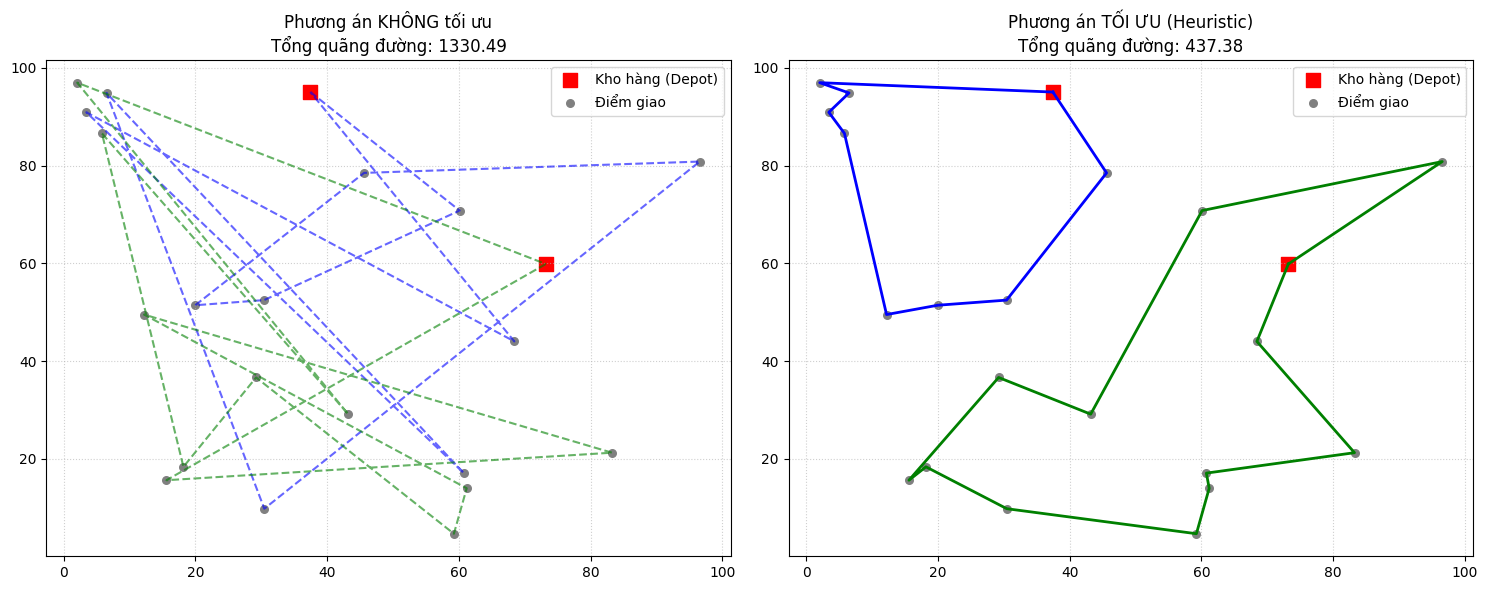

--- ĐÁNH GIÁ HIỆU QUẢ ---
Quãng đường phương án ngẫu nhiên: 1330.49 đơn vị
Quãng đường phương án tối ưu (Heuristic): 437.38 đơn vị
Tiết kiệm được: 893.11 đơn vị (Tương đương giảm 67.13%)


In [125]:
#23.12
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

# 1. Khởi tạo dữ liệu giả lập
np.random.seed(42) # Cố định seed để kết quả không đổi sau mỗi lần chạy
num_depots = 2      # Số lượng kho hàng
num_customers = 20  # Số lượng điểm giao nhận

# Tạo tọa độ ngẫu nhiên trên bản đồ (lưới 100x100)
depots = np.random.rand(num_depots, 2) * 100
customers = np.random.rand(num_customers, 2) * 100

# Hàm tính tổng quãng đường của một tuyến
def calculate_route_distance(route, coords):
    dist = 0
    for i in range(len(route) - 1):
        dist += distance.euclidean(coords[route[i]], coords[route[i+1]])
    return dist

# 2. Xây dựng phương án KHÔNG tối ưu (Ngẫu nhiên)
# Gán ngẫu nhiên và đi ngẫu nhiên
unoptimized_routes = {i: [] for i in range(num_depots)}
customer_indices = list(range(num_customers))
np.random.shuffle(customer_indices)

# Chia đều khách hàng cho các kho một cách ngẫu nhiên
for i, cust_idx in enumerate(customer_indices):
    unoptimized_routes[i % num_depots].append(cust_idx)

unoptimized_total_dist = 0
unoptimized_full_paths = [] # Lưu lại để vẽ

for depot_idx, cust_list in unoptimized_routes.items():
    # Tuyến đường: Kho -> Các điểm ngẫu nhiên -> Kho
    route_coords = [depots[depot_idx]] + [customers[i] for i in cust_list] + [depots[depot_idx]]
    dist = calculate_route_distance(list(range(len(route_coords))), route_coords)
    unoptimized_total_dist += dist
    unoptimized_full_paths.append(route_coords)

# 3. Xây dựng phương án TỐI ƯU (Dùng Heuristic: Nearest Depot + Nearest Neighbor)
optimized_routes = {i: [] for i in range(num_depots)}
#  3.1: Gán điểm giao cho kho gần nhất
for i, cust in enumerate(customers):
    distances_to_depots = [distance.euclidean(cust, d) for d in depots]
    closest_depot = np.argmin(distances_to_depots)
    optimized_routes[closest_depot].append(i)

optimized_total_dist = 0
optimized_full_paths = []

#  3.2: Lập tuyến bằng Nearest Neighbor cho từng kho
for depot_idx, cust_list in optimized_routes.items():
    if not cust_list: continue

    current_loc = depots[depot_idx]
    unvisited = cust_list.copy()
    route_coords = [current_loc]

    while unvisited:
        # Tìm điểm chưa thăm gần nhất
        distances = [distance.euclidean(current_loc, customers[j]) for j in unvisited]
        nearest_idx = np.argmin(distances)
        next_customer = unvisited.pop(nearest_idx)

        current_loc = customers[next_customer]
        route_coords.append(current_loc)

    route_coords.append(depots[depot_idx]) # Quay về kho
    dist = calculate_route_distance(list(range(len(route_coords))), route_coords)
    optimized_total_dist += dist
    optimized_full_paths.append(route_coords)

# 4. Trực quan hóa kết quả (Bản đồ)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = ['blue', 'green', 'purple', 'orange']

# Biểu đồ 1: Không tối ưu
ax1.set_title(f"Phương án KHÔNG tối ưu\nTổng quãng đường: {unoptimized_total_dist:.2f}")
ax1.scatter(depots[:, 0], depots[:, 1], c='red', marker='s', s=100, label='Kho hàng (Depot)')
ax1.scatter(customers[:, 0], customers[:, 1], c='gray', marker='o', s=30, label='Điểm giao')
for i, path in enumerate(unoptimized_full_paths):
    path = np.array(path)
    ax1.plot(path[:, 0], path[:, 1], c=colors[i % len(colors)], linestyle='--', alpha=0.6)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Biểu đồ 2: Tối ưu bằng Heuristic
ax2.set_title(f"Phương án TỐI ƯU (Heuristic)\nTổng quãng đường: {optimized_total_dist:.2f}")
ax2.scatter(depots[:, 0], depots[:, 1], c='red', marker='s', s=100, label='Kho hàng (Depot)')
ax2.scatter(customers[:, 0], customers[:, 1], c='gray', marker='o', s=30, label='Điểm giao')
for i, path in enumerate(optimized_full_paths):
    path = np.array(path)
    ax2.plot(path[:, 0], path[:, 1], c=colors[i % len(colors)], linestyle='-', linewidth=2)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# In kết quả đánh giá
print("--- ĐÁNH GIÁ HIỆU QUẢ ---")
print(f"Quãng đường phương án ngẫu nhiên: {unoptimized_total_dist:.2f} đơn vị")
print(f"Quãng đường phương án tối ưu (Heuristic): {optimized_total_dist:.2f} đơn vị")
print(f"Tiết kiệm được: {unoptimized_total_dist - optimized_total_dist:.2f} đơn vị (Tương đương giảm {((unoptimized_total_dist - optimized_total_dist)/unoptimized_total_dist)*100:.2f}%)")

-Đánh giá ss 23.12
Với số liệu ngẫu nhiên ở trên, Heuristic thường giúp tiết kiệm từ 50% đến 70% quãng đường di chuyển so với việc không có kế hoạch, giúp giảm thiểu chi phí nhiên liệu và thời gian.


In [126]:
#23.13

import folium
from folium import plugins
import requests

# 1. Hàm lấy tọa độ đường đi thực tế từ OSRM
def get_real_route(start, end):
    url = f"http://router.project-osrm.org/route/v1/driving/{start[1]},{start[0]};{end[1]},{end[0]}?overview=full&geometries=geojson"
    try:
        response = requests.get(url).json()
        route = response['routes'][0]['geometry']['coordinates']
        distance = response['routes'][0]['distance']
        return [[c[1], c[0]] for c in route], distance
    except:
        return [start, end], 0

# 2. Khởi tạo bản đồ trung tâm TP.HCM
m = folium.Map(location=[10.7769, 106.7009], zoom_start=13, tiles='OpenStreetMap')

# Tạo các lớp (Layers)
layer_points = folium.FeatureGroup(name='Điểm: Hệ thống Kho hàng')
layer_regions = folium.FeatureGroup(name='Vùng: Nhu cầu cao')
layer_routes = folium.FeatureGroup(name='Tuyến: Đường vận chuyển thực tế')

# 3. LỚP ĐIỂM (POINTS) - CHI TIẾT THÔNG TIN KHO

kho_data = {
    "Kho Trung Tâm": {
        "coords": [10.7769, 106.7009],
        "info": """
            <h4 style='margin-bottom:5px;'>Kho Trung Tâm (Q1)</h4>
            <b>Tổng sức chứa:</b> 10,000 TEU<br>
            <b>Công suất hiện tại:</b> 85%<br>
            <b>Trạng thái:</b> Hoạt động ổn định<br>
            <b>Quản lý:</b> Nguyễn Văn A
        """,
        "color": "red"
    },
    "Kho Vệ Tinh Q2": {
        "coords": [10.7950, 106.7200],
        "info": """
            <h4 style='margin-bottom:5px;'>Kho Vệ Tinh (Q2)</h4>
            <b>Tổng sức chứa:</b> 3,000 TEU<br>
            <b>Công suất hiện tại:</b> 95%<br>
            <b>Trạng thái:</b> <span style='color:red;'>Cảnh báo quá tải</span><br>
            <b>Quản lý:</b> Trần Văn B
        """,
        "color": "darkred"
    }
}

for name, data in kho_data.items():
    folium.Marker(
        location=data["coords"],
        popup=folium.Popup(data["info"], max_width=300),
        tooltip="Click để xem thông số kho",
        icon=folium.Icon(color=data["color"], icon='info-sign')
    ).add_to(layer_points)
# 4. LỚP VÙNG (POLYGONS) & TUYẾN (LINES)

region_coords = [[10.785, 106.700], [10.795, 106.710], [10.775, 106.720], [10.765, 106.710]]
folium.Polygon(
    locations=region_coords, color='orange', fill=True, fill_opacity=0.3,
    popup="<b>Khu vực V.I.P</b><br>Nhu cầu giao hàng tăng vọt 40%"
).add_to(layer_regions)

# Tuyến đường
route_coords, dist = get_real_route(kho_data["Kho Trung Tâm"]["coords"], kho_data["Kho Vệ Tinh Q2"]["coords"])
folium.PolyLine(
    locations=route_coords, color='blue', weight=5, opacity=0.8,
    popup=f"Tuyến đường thực tế: {dist/1000:.2f} km"
).add_to(layer_routes)

# 5. TÍCH HỢP CONTROL

layer_points.add_to(m)
layer_regions.add_to(m)
layer_routes.add_to(m)

folium.LayerControl().add_to(m)
m.add_child(plugins.MeasureControl(position='topleft', primary_length_unit='kilometers', secondary_length_unit='meters'))
m

In [127]:
#23.14
import osmnx as ox
import networkx as nx
import pandas as pd
import plotly.express as px


# 1. TẢI DỮ LIỆU ĐƯỜNG PHỐ THỰC TẾ (Khu vực trung tâm HCMC)

print("Đang tải dữ liệu bản đồ từ OpenStreetMap... (Có thể mất 10-30 giây)")
center_point = (10.7769, 106.6850) # Tọa độ trung tâm (Khu vực Q3, Q10)

# Tải mạng lưới đường bộ (chỉ lấy đường cho xe chạy) trong bán kính 3km
G = ox.graph_from_point(center_point, dist=3000, network_type='drive')
print("Tải bản đồ hoàn tất!")


# 2. KHỞI TẠO TỌA ĐỘ VÀ TÌM ĐIỂM KHỚP TRÊN ĐƯỜNG THỰC TẾ

locations = {
    'Kho_Q10': (10.7734, 106.6660),      # Gần khu vực cơ sở B UEH
    'DiemGiao_Q1': (10.7769, 106.7009),  # Chợ Bến Thành
    'DiemGiao_Q3': (10.7845, 106.6850),  # Ngã 6 Cộng Hòa
    'DiemGiao_PN': (10.7950, 106.6800)   # Khu vực Phú Nhuận
}

# Tìm Node (nút giao thông hoặc đoạn đường) gần nhất trên OSM cho mỗi tọa độ
nodes_osm = {}
for name, (lat, lon) in locations.items():
    # Lưu ý: osmnx nhận X=lon, Y=lat
    nodes_osm[name] = ox.distance.nearest_nodes(G, X=lon, Y=lat)


# 3. ĐIỀU PHỐI VÀ CHẠY THUẬT TOÁN DIJKSTRA (Routing)

vehicles = [
    {'id': 'Xe Tải 01', 'tasks': ['Kho_Q10', 'DiemGiao_Q1', 'DiemGiao_Q3']},
    {'id': 'Xe Bán Tải 02', 'tasks': ['Kho_Q10', 'DiemGiao_PN', 'DiemGiao_Q1']}
]

vehicle_paths_coords = {}
max_steps = 0

for v in vehicles:
    full_path_nodes = []
    tasks = v['tasks']

    # Tính đường đi ngắn nhất giữa các điểm giao nhận liên tiếp
    for i in range(len(tasks) - 1):
        start_node = nodes_osm[tasks[i]]
        end_node = nodes_osm[tasks[i+1]]

        # Thuật toán Dijkstra tìm đường đi ngắn nhất theo trọng số là chiều dài thực tế (length)
        route = nx.shortest_path(G, source=start_node, target=end_node, weight='length')

        # Nối lộ trình (bỏ node đầu tiên của chặng sau để tránh xe bị đứng yên 1 nhịp)
        if i == 0:
            full_path_nodes.extend(route)
        else:
            full_path_nodes.extend(route[1:])

    # Trích xuất lại (Vĩ độ, Kinh độ) từ các Node ID trong lộ trình để vẽ lên bản đồ
    route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in full_path_nodes]
    vehicle_paths_coords[v['id']] = route_coords

    # Tìm khoảng thời gian dài nhất (lộ trình nhiều node nhất) để set animation
    max_steps = max(max_steps, len(route_coords))


# 4. CHUẨN BỊ DỮ LIỆU ĐỂ TRỰC QUAN HÓA THEO THỜI GIAN THỰC

simulation_data = []

for t in range(max_steps):
    for v_id, coords in vehicle_paths_coords.items():
        # Nếu xe đi nhanh và đã tới đích trước, cho xe đứng yên ở điểm cuối
        current_step = min(t, len(coords) - 1)
        lat, lon = coords[current_step]
        status = "Đang di chuyển" if t < len(coords) - 1 else "Đã hoàn thành chuyến"

        simulation_data.append({
            'TimeStep': t,
            'VehicleID': v_id,
            'Lat': lat,
            'Lon': lon,
            'Status': status
        })

df_sim = pd.DataFrame(simulation_data)


# 5. TRỰC QUAN HÓA LÊN BẢN ĐỒ VỚI PLOTLY

fig = px.scatter_mapbox(
    df_sim,
    lat="Lat",
    lon="Lon",
    color="VehicleID",
    hover_name="VehicleID",
    hover_data=["Status"],
    animation_frame="TimeStep",
    title="Mô phỏng Điều phối Giao hàng Thực tế (OSM + Dijkstra)",
    mapbox_style="open-street-map",
    zoom=13,
    center={"lat": 10.78, "lon": 106.685}, # Center map về khu vực đã tải
    size_max=15
)

# Tùy chỉnh độ lớn marker xe
fig.update_traces(marker=dict(size=12))

# Chỉnh tốc độ phát của animation (mili giây/frame) - số càng nhỏ chạy càng nhanh
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 80

fig.show()

Đang tải dữ liệu bản đồ từ OpenStreetMap... (Có thể mất 10-30 giây)
Tải bản đồ hoàn tất!


In [128]:
#23.15
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import folium


# 1: TẠO DỮ LIỆU GIẢ LẬP

# Thiết lập seed để dữ liệu không đổi sau mỗi lần chạy
np.random.seed(42)
num_points = 100

# Tọa độ trung tâm (Khu vực trung tâm TP.HCM)
base_lat, base_lon = 10.7769, 106.7009

# Tạo danh sách các điểm giao hàng ngẫu nhiên xung quanh khu vực trung tâm
data = {
    'Mã đơn hàng': [f"ORD_{i:03d}" for i in range(num_points)],
    'Latitude': base_lat + np.random.uniform(-0.06, 0.06, num_points),
    'Longitude': base_lon + np.random.uniform(-0.06, 0.06, num_points)
}
df = pd.DataFrame(data)


# 2: ÁP DỤNG AI (K-MEANS CLUSTERING)

# Giả sử chúng ta có 5 shipper, cần chia thành 5 cụm
num_clusters = 5

# Khởi tạo và huấn luyện mô hình K-Means
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Latitude', 'Longitude']])

# Lấy tọa độ trung tâm của các cụm (để làm các Trạm trung chuyển - Hubs)
centers = kmeans.cluster_centers_

# 3: TRỰC QUAN HÓA BẢN ĐỒ VỚI FOLIUM

# Khởi tạo bản đồ tập trung vào TP.HCM
m = folium.Map(location=[base_lat, base_lon], zoom_start=13, tiles='CartoDB Positron')

# Định nghĩa màu sắc cho 5 cụm
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231']

# 3.1 Vẽ các điểm giao hàng
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        color=colors[row['Cluster']],
        fill=True,
        fill_color=colors[row['Cluster']],
        fill_opacity=0.8,
        weight=1,
        popup=f"Đơn hàng: {row['Mã đơn hàng']}<br>Khu vực: {row['Cluster']}"
    ).add_to(m)

# 3.2 Vẽ các Trạm trung chuyển (Hubs) / Trọng tâm cụm
for i, center in enumerate(centers):
    folium.Marker(
        location=[center[0], center[1]],
        icon=folium.Icon(color='darkblue', icon='cloud', prefix='glyphicon'),
        popup=f"<b>Hub khu vực {i}</b>"
    ).add_to(m)
m

-23.15
1. Trình bày bài toán
Trong quản trị chuỗi cung ứng, khâu Giao hàng chặng cuối (Last-mile Delivery) luôn chiếm tỷ trọng chi phí lớn nhất và phức tạp nhất. Bài toán đặt ra đối với một trung tâm điều phối logistics tại các đô thị lớn (như TP.HCM) là phải xử lý hàng trăm đến hàng ngàn đơn hàng phát sinh liên tục mỗi ngày.
Nếu phân bổ đơn hàng cho shipper một cách thủ công hoặc ngẫu nhiên, hệ thống sẽ đối mặt với các vấn đề:
Shipper phải di chuyển các quãng đường chéo ngoe, trùng lặp tuyến đường của nhau.
Khối lượng công việc giữa các nhân viên không đồng đều (người chạy quá nhiều, người ít việc).
Giao hàng trễ giờ (vi phạm SLA - Service Level Agreement).
Mục tiêu giải quyết: Xây dựng một hệ thống tự động phân nhóm (gom cụm) các đơn hàng dựa trên vị trí địa lý. Mỗi cụm sẽ tương ứng với một khu vực phụ trách của một shipper hoặc một trạm trung chuyển nhỏ (micro-hub), nhằm thu hẹp bán kính hoạt động và tối ưu hóa nguồn lực.
2. Dữ liệu đầu vào (Data)
Để mô hình AI hoạt động, bài toán sử dụng tập dữ liệu không gian (Spatial Data).
Dữ liệu mô phỏng trong bài: Tập hợp tọa độ địa lý bao gồm Vĩ độ (Latitude) và Kinh độ (Longitude) của các điểm cần giao hàng. Mỗi điểm được gắn một mã định danh (Order ID).
Dữ liệu thực tế (nếu mở rộng): Trong môi trường thực tế, dữ liệu này có thể được trích xuất từ hệ thống ERP hoặc OMS (Order Management System), kết hợp thêm các trường dữ liệu như: Khung giờ yêu cầu giao, kích thước/trọng lượng hàng hóa, và dữ liệu tình trạng kẹt xe theo thời gian thực (Traffic API).
3. Phương pháp AI: Học máy không giám sát (Unsupervised Learning)
Bài toán áp dụng thuật toán K-Means Clustering, một trong những phương pháp phân cụm dữ liệu mạnh mẽ và phổ biến nhất trong quản lý không gian.
Cách thức hoạt động: K-Means sẽ tự động tìm kiếm các mẫu (patterns) trong dữ liệu tọa độ mà không cần được gán nhãn trước. Thuật toán cố gắng chia $N$ điểm giao hàng vào $K$ cụm (với $K$ là số lượng shipper hoặc xe tải có sẵn) sao cho tổng bình phương khoảng cách từ các điểm giao hàng đến trung tâm của cụm (centroid) là nhỏ nhất.
Lý do lựa chọn: Thuật toán này tính toán cực kỳ nhanh, phù hợp với các bài toán điều phối có tính thời gian thực (real-time dispatching) khi đơn hàng mới liên tục đổ về hệ thống.
4. Trực quan hóa bản đồ
Kết quả của mô hình AI không chỉ là những con số vô tri mà được "bản đồ hóa" thành một Dashboard quản trị trực quan:
Phân vùng theo màu sắc: Các điểm giao hàng được tô màu khác nhau dựa trên cụm (cluster) mà AI đã phân bổ. Quản lý có thể nhìn lướt qua là biết ranh giới hoạt động của từng shipper mà không cần đọc bảng biểu phức tạp.
Định vị trung tâm (Hubs): Các điểm đánh dấu nổi bật (Markers/Icons) đại diện cho tọa độ trung tâm của mỗi cụm. Đây là tính năng trực quan giúp nhà quản trị nhìn thấy ngay vị trí lý tưởng nhất để thả hàng xuống cho shipper bắt đầu tuyến đi.
5. Giá trị ứng dụng thực tiễn
Mô hình này mang lại những giá trị cốt lõi trong quản trị vận hành và công nghệ:
Tối ưu hóa Chi phí (Cost Reduction): Giảm thiểu tổng quãng đường di chuyển của toàn bộ đội xe, từ đó tiết kiệm nhiên liệu và giảm khấu hao phương tiện.
Cân bằng tải (Workload Balancing): Đảm bảo không có khu vực nào bị quá tải đơn hàng. Quản lý có thể linh hoạt tăng hoặc giảm tham số $K$ (số lượng cụm) dựa trên số lượng nhân sự đang ca làm việc hôm đó.
Hỗ trợ ra quyết định chiến lược (Strategic Planning): Tọa độ trung tâm (Centroids) do AI gợi ý chính là cơ sở dữ liệu tuyệt vời để doanh nghiệp quyết định vị trí thuê kho bãi (Warehouse), trạm chia chọn nhỏ (Micro-fulfillment centers) hoặc bưu cục mới trong tương lai.
